In [1]:
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
DATA_PATH = Path('energydata_complete.csv')
optuna.logging.set_verbosity(optuna.logging.WARNING)


## 1. Business framing and validation design

Target: `Appliances` energy consumption. This is regression, not classification.
We keep chronological order: first 80% for training, last 20% as unseen future data.
Random splitting is intentionally avoided because it allows future patterns into train.


In [2]:
raw = pd.read_csv(DATA_PATH)
raw['date'] = pd.to_datetime(raw['date'], errors='coerce')
raw = raw.dropna(subset=['date']).sort_values('date').drop_duplicates().reset_index(drop=True)
target_name = 'Appliances'
print(f'Rows: {len(raw):,} | Columns: {raw.shape[1]}')
print(f'Date range: {raw.date.min()} -> {raw.date.max()}')
print(f'Missing cells: {raw.isna().sum().sum()} | Duplicate rows: {raw.duplicated().sum()}')
display(raw.head(), raw.describe(include='all').T.head(10))


Rows: 19,735 | Columns: 29
Date range: 2016-01-11 17:00:00 -> 2016-05-27 18:00:00
Missing cells: 0 | Duplicate rows: 0


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


,count,mean,min,25%,50%,75%,max,std
date,19735,2016-03-20 05:30:00,2016-01-11 17:00:00,2016-02-14 23:15:00,2016-03-20 05:30:00,2016-04-23 11:45:00,2016-05-27 18:00:00,NaN
Appliances,19735.0,97.694958,10.0,50.0,60.0,100.0,1080.0,102.524891
lights,19735.0,3.801875,0.0,0.0,0.0,0.0,70.0,7.935988
T1,19735.0,21.686571,16.79,20.76,21.6,22.6,26.26,1.606066
RH_1,19735.0,40.259739,27.023333,37.333333,39.656667,43.066667,63.36,3.979299
T2,19735.0,20.341219,16.1,18.79,20.0,21.5,29.856667,2.192974
RH_2,19735.0,40.42042,20.463333,37.9,40.5,43.26,56.026667,4.069813
T3,19735.0,22.267611,17.2,20.79,22.1,23.29,29.236,2.006111
RH_3,19735.0,39.2425,28.766667,36.9,38.53,41.76,50.163333,3.254576
T4,19735.0,20.855335,15.1,19.53,20.666667,22.1,26.2,2.042884


## 2. EDA: trend, seasonality, outliers and correlations

High consumption values are not removed: they may be real appliance events.


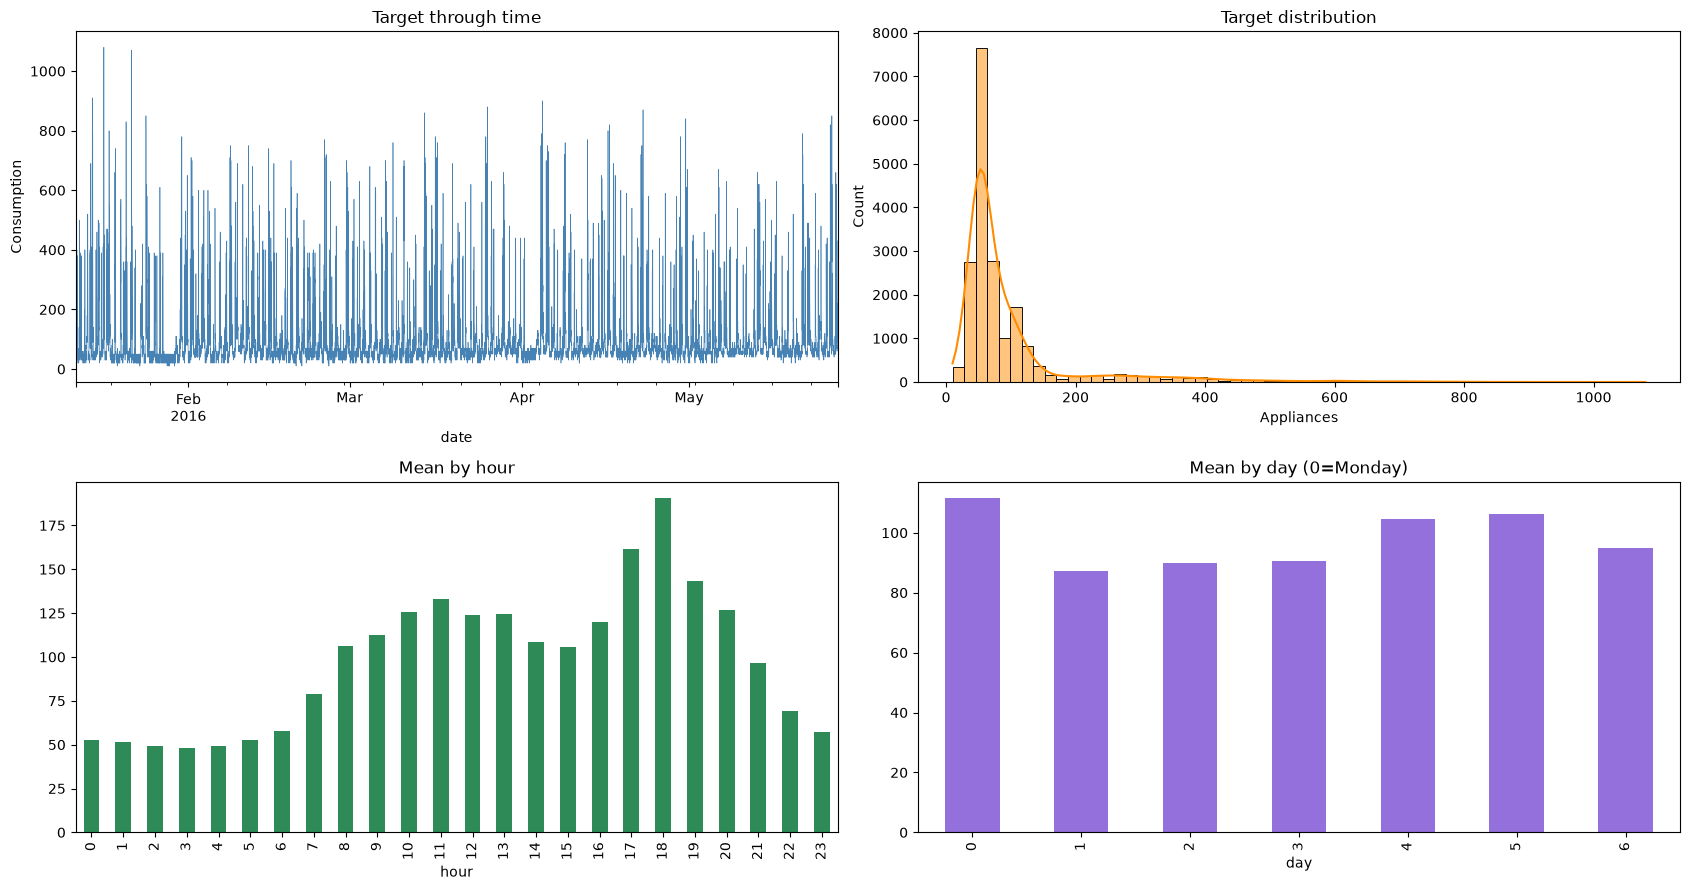

Target quantiles:


,consumption
0.010,20.0
0.250,50.0
0.500,60.0
0.750,100.0
0.950,330.0
0.990,576.6
0.999,790.0


,correlation
Appliances,1.000000
lights,0.197278
T2,0.120073
T6,0.117638
T_out,0.099155
Windspeed,0.087122
RH_1,0.086031
T3,0.085060
T1,0.055447
T4,0.040281


In [3]:
eda = raw.set_index('date')
fig, axes = plt.subplots(2, 2, figsize=(17, 9))
eda[target_name].plot(ax=axes[0,0], linewidth=.45, color='steelblue')
axes[0,0].set_title('Target through time'); axes[0,0].set_ylabel('Consumption')
sns.histplot(raw[target_name], bins=60, kde=True, ax=axes[0,1], color='darkorange')
axes[0,1].set_title('Target distribution')
hour = raw.assign(hour=raw.date.dt.hour).groupby('hour')[target_name].mean()
hour.plot(kind='bar', ax=axes[1,0], color='seagreen'); axes[1,0].set_title('Mean by hour')
dow = raw.assign(day=raw.date.dt.dayofweek).groupby('day')[target_name].mean()
dow.plot(kind='bar', ax=axes[1,1], color='mediumpurple'); axes[1,1].set_title('Mean by day (0=Monday)')
plt.tight_layout(); plt.show()

print('Target quantiles:')
display(raw[target_name].quantile([.01,.25,.5,.75,.95,.99,.999]).to_frame('consumption'))
numeric_corr = raw.select_dtypes('number').corr()[target_name].sort_values(ascending=False)
display(numeric_corr.head(12).to_frame('correlation'))


## 3. Leakage-safe feature engineering

The dataset is recorded every 10 minutes: 6 rows/hour, 144 rows/day, 1008 rows/week.
Lag and rolling features use `shift(1)`, so the current target never leaks into its own features.


In [4]:
def make_features(frame):
    z = frame.copy().sort_values('date').reset_index(drop=True)
    dt = z['date']
    z['month'] = dt.dt.month
    z['day_of_month'] = dt.dt.day
    z['day_of_week'] = dt.dt.dayofweek
    z['hour'] = dt.dt.hour
    z['minute'] = dt.dt.minute
    z['is_weekend'] = (z['day_of_week'] >= 5).astype(int)
    slot = z['hour'] * 6 + z['minute'] // 10
    z['time_sin'] = np.sin(2*np.pi*slot/144)
    z['time_cos'] = np.cos(2*np.pi*slot/144)
    z['dow_sin'] = np.sin(2*np.pi*z['day_of_week']/7)
    z['dow_cos'] = np.cos(2*np.pi*z['day_of_week']/7)
    y = z[target_name].copy()
    for lag in [1, 2, 3, 6, 12, 18, 36, 72, 144, 288, 1008]:
        z[f'lag_{lag}'] = y.shift(lag)
    for window in [6, 18, 36, 144]:
        past = y.shift(1)
        z[f'rolling_mean_{window}'] = past.rolling(window).mean()
        z[f'rolling_std_{window}'] = past.rolling(window).std()
    y_out = z[target_name]
    X_out = z.drop(columns=['date', target_name, 'rv2'], errors='ignore')
    valid = X_out.notna().all(axis=1)
    return X_out.loc[valid].reset_index(drop=True), y_out.loc[valid].reset_index(drop=True), z.loc[valid, 'date'].reset_index(drop=True)

X, y, dates = make_features(raw)
split = int(len(X) * .8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
print(f'Feature matrix: {X.shape} | train: {X_train.shape} | future test: {X_test.shape}')


Feature matrix: (18727, 55) | train: (14981, 55) | future test: (3746, 55)


## 4. Baselines and chronological cross-validation

The naive forecast (last known value) is mandatory. A complex model is useful only
if it beats this baseline on future data.


In [5]:
def make_pipeline(estimator):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler', RobustScaler()), ('model', estimator)])

def metrics(actual, predicted):
    return {'R2': r2_score(actual, predicted),
            'MAE': mean_absolute_error(actual, predicted),
            'RMSE': mean_squared_error(actual, predicted) ** .5}

def cv_score(estimator, X_data=X_train, y_data=y_train, n_splits=4):
    rows = []
    for train_idx, val_idx in TimeSeriesSplit(n_splits=n_splits).split(X_data):
        model = make_pipeline(clone(estimator))
        model.fit(X_data.iloc[train_idx], y_data.iloc[train_idx])
        rows.append(metrics(y_data.iloc[val_idx], model.predict(X_data.iloc[val_idx])))
    return pd.DataFrame(rows).mean()

candidate_models = {
    'Ridge': Ridge(alpha=10.0),
    'Extra Trees': ExtraTreesRegressor(n_estimators=250, min_samples_leaf=2, max_features=.8, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=18, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'Hist Gradient Boosting': HistGradientBoostingRegressor(max_iter=250, learning_rate=.05, max_leaf_nodes=31, l2_regularization=1.0, random_state=RANDOM_STATE),
}
cv_results = []
for name, estimator in candidate_models.items():
    score = cv_score(estimator)
    cv_results.append([name, score.R2, score.MAE, score.RMSE])
cv_table = pd.DataFrame(cv_results, columns=['Model','R2','MAE','RMSE']).sort_values('RMSE')
display(cv_table.style.format({'R2':'{:.4f}','MAE':'{:.2f}','RMSE':'{:.2f}'}))


,Model,R2,MAE,RMSE
1,Extra Trees,0.5890,32.93,64.76
0,Ridge,0.5610,33.33,66.98
3,Hist Gradient Boosting,0.5507,36.89,67.56
2,Random Forest,0.5508,35.77,67.73


## 5. Optuna hyperparameter tuning

Optuna minimises chronological validation RMSE. The test set remains untouched until the end.


Best CV RMSE: 63.035
Best parameters: {'max_iter': 161, 'learning_rate': 0.03451958620131221, 'max_leaf_nodes': 19, 'min_samples_leaf': 58, 'l2_regularization': 0.07818241443918982}


<Axes: title={'center': 'Optimization History Plot'}, xlabel='Trial', ylabel='Objective Value'>

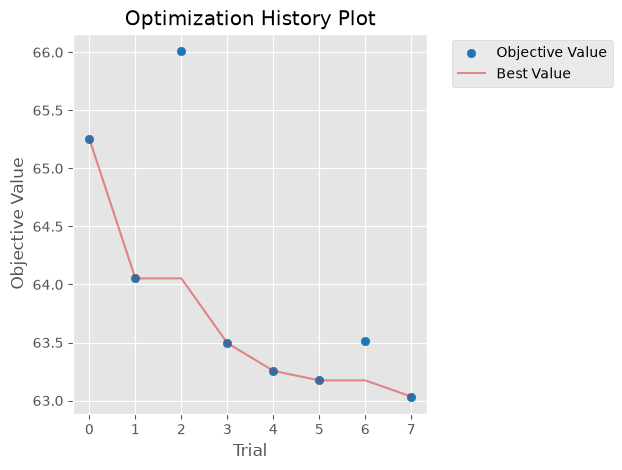

In [6]:
def objective(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 80, 180),
        'learning_rate': trial.suggest_float('learning_rate', .02, .12, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 15, 63),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 80),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-3, 20, log=True),
    }
    scores = []
    for tr_idx, va_idx in TimeSeriesSplit(n_splits=2).split(X_train):
        model = make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params))
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        pred = model.predict(X_train.iloc[va_idx])
        scores.append(mean_squared_error(y_train.iloc[va_idx], pred) ** .5)
    return float(np.mean(scores))

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=8, show_progress_bar=False)
print('Best CV RMSE:', round(study.best_value, 3))
print('Best parameters:', study.best_params)
display(optuna.visualization.matplotlib.plot_optimization_history(study)); plt.show()


## 6. Final future holdout score


In [7]:
tuned_model = make_pipeline(HistGradientBoostingRegressor(random_state=RANDOM_STATE, **study.best_params))
tuned_model.fit(X_train, y_train)
pred = tuned_model.predict(X_test)
naive = X_test['lag_1'].to_numpy()
final_scores = pd.DataFrame([
    ['Naive previous value', *metrics(y_test, naive).values()],
    ['Tuned Hist Gradient Boosting', *metrics(y_test, pred).values()],
], columns=['Model','R2','MAE','RMSE'])
display(final_scores.style.format({'R2':'{:.4f}','MAE':'{:.2f}','RMSE':'{:.2f}'}))


,Model,R2,MAE,RMSE
0,Naive previous value,0.4511,25.68,64.65
1,Tuned Hist Gradient Boosting,0.5626,27.18,57.72


## 7. Error analysis

We inspect residual distribution, error over time, error by hour, and the worst misses.
This tells us where the model fails instead of hiding behind one score.


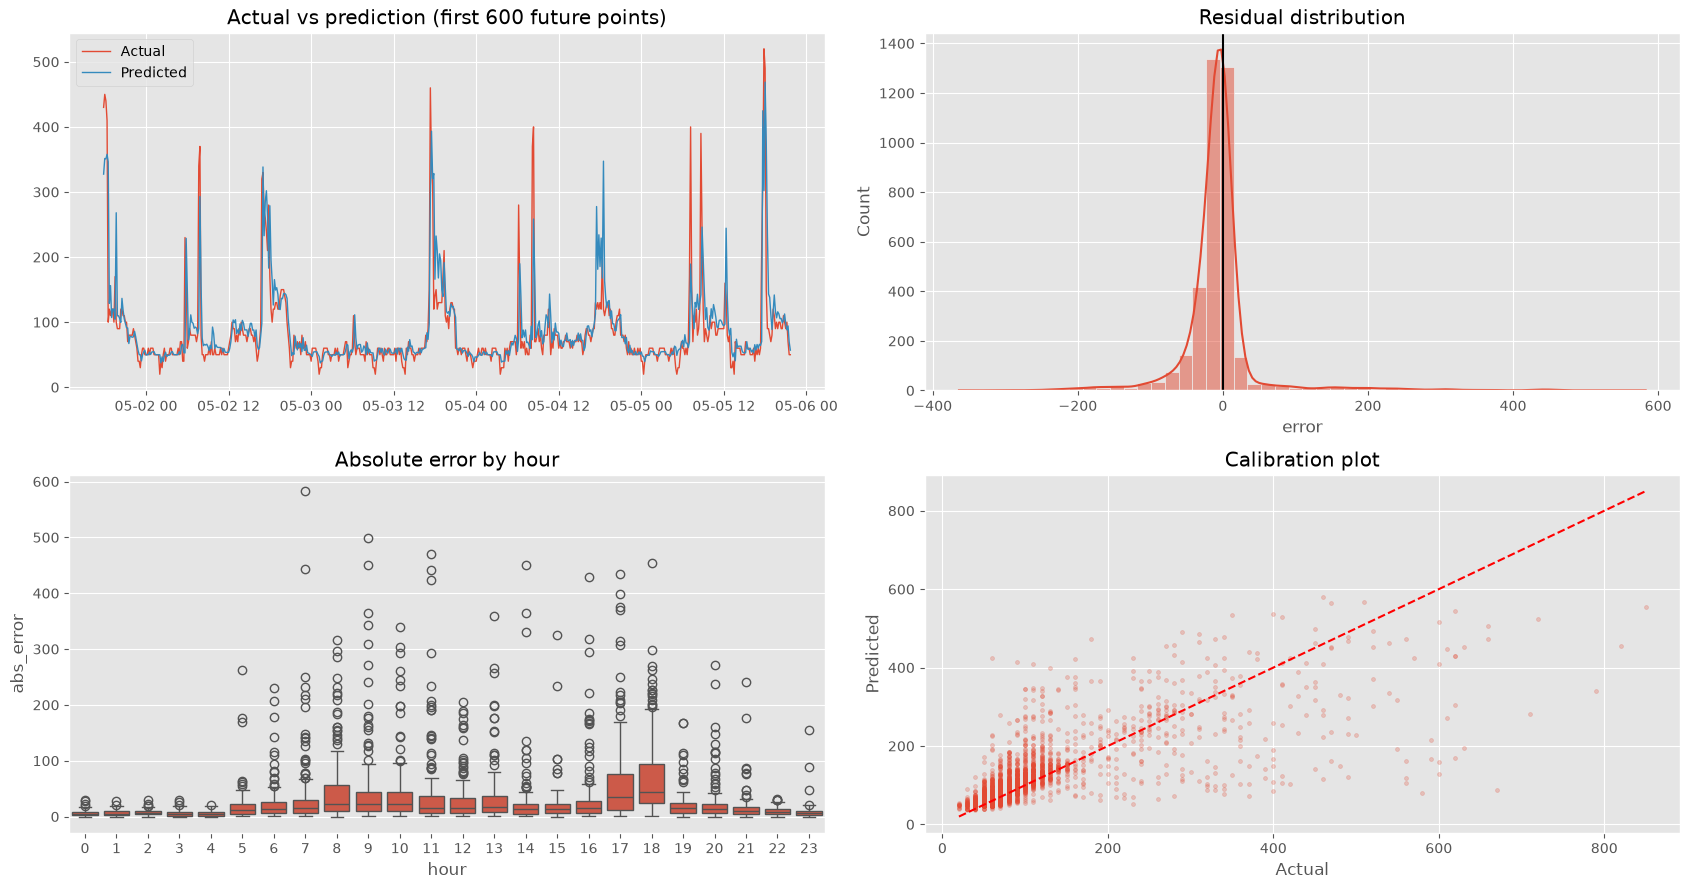

Residual mean: -6.103 | Positive means under-prediction.


,date,actual,predicted,error,abs_error,hour,day_of_week,pct_error
658,2016-05-06 07:30:00,670,87.205338,582.794662,582.794662,7,4,86.984278
3695,2016-05-27 09:40:00,580,81.089785,498.910215,498.910215,9,4,86.019003
1688,2016-05-13 11:10:00,600,129.278355,470.721645,470.721645,11,4,78.453608
866,2016-05-07 18:10:00,560,106.709657,453.290343,453.290343,18,5,80.944704
2831,2016-05-21 09:40:00,790,339.002568,450.997432,450.997432,9,5,57.088282
1707,2016-05-13 14:20:00,620,169.540032,450.459968,450.459968,14,4,72.654834
1668,2016-05-13 07:50:00,560,117.230987,442.769013,442.769013,7,4,79.065895
3563,2016-05-26 11:40:00,600,158.051556,441.948444,441.948444,11,3,73.658074
2159,2016-05-16 17:40:00,630,195.731949,434.268051,434.268051,17,0,68.931437
3592,2016-05-26 16:30:00,710,281.210120,428.789880,428.789880,16,3,60.392941


,mean_abs_error,mean_signed_error,count
hour,,,
18,73.370703,-50.254758,157
17,63.472781,3.558920,157
9,47.810469,-6.988820,156
8,47.187256,-4.707386,156
11,41.879313,3.134301,156
10,40.837927,-14.595032,156
7,37.487991,2.708669,156
13,36.228736,-11.637718,156
16,34.205862,0.227512,156


In [8]:
errors = pd.DataFrame({'date': dates.iloc[split:].values, 'actual': y_test.values,
                       'predicted': pred, 'error': y_test.values - pred})
errors['abs_error'] = errors['error'].abs()
errors['hour'] = errors.date.dt.hour
errors['day_of_week'] = errors.date.dt.dayofweek
errors['pct_error'] = errors['abs_error'] / np.maximum(errors['actual'], 1) * 100
fig, ax = plt.subplots(2, 2, figsize=(17, 9))
ax[0,0].plot(errors.date.iloc[:600], errors.actual.iloc[:600], label='Actual', linewidth=1)
ax[0,0].plot(errors.date.iloc[:600], errors.predicted.iloc[:600], label='Predicted', linewidth=1)
ax[0,0].set_title('Actual vs prediction (first 600 future points)'); ax[0,0].legend()
sns.histplot(errors.error, bins=50, kde=True, ax=ax[0,1]); ax[0,1].axvline(0, color='black'); ax[0,1].set_title('Residual distribution')
sns.boxplot(data=errors, x='hour', y='abs_error', ax=ax[1,0]); ax[1,0].set_title('Absolute error by hour')
ax[1,1].scatter(errors.actual, errors.predicted, s=8, alpha=.25)
lims=[errors.actual.min(), errors.actual.max()]; ax[1,1].plot(lims, lims, 'r--'); ax[1,1].set_xlabel('Actual'); ax[1,1].set_ylabel('Predicted'); ax[1,1].set_title('Calibration plot')
plt.tight_layout(); plt.show()
print('Residual mean:', round(errors.error.mean(), 3), '| Positive means under-prediction.')
display(errors.sort_values('abs_error', ascending=False).head(15))
display(errors.groupby('hour').agg(mean_abs_error=('abs_error','mean'), mean_signed_error=('error','mean'), count=('error','size')).sort_values('mean_abs_error', ascending=False))


## 8. Feature importance and final interpretation


,feature,importance
36,lag_1,52.672000
37,lag_2,16.153146
52,rolling_std_36,0.359333
47,rolling_mean_6,0.269093
49,rolling_mean_18,0.235058
33,time_cos,0.215925
50,rolling_std_18,0.189109
38,lag_3,0.168052
40,lag_12,0.103924
5,T3,0.078766


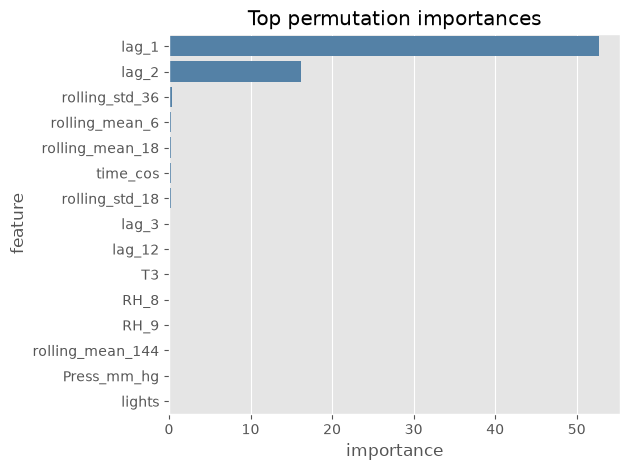

Workflow complete: compare the final holdout table, then use the error analysis to decide the next feature or model improvement.


,feature,importance
36,lag_1,52.672000
37,lag_2,16.153146
52,rolling_std_36,0.359333
47,rolling_mean_6,0.269093
49,rolling_mean_18,0.235058
33,time_cos,0.215925
50,rolling_std_18,0.189109
38,lag_3,0.168052
40,lag_12,0.103924
5,T3,0.078766


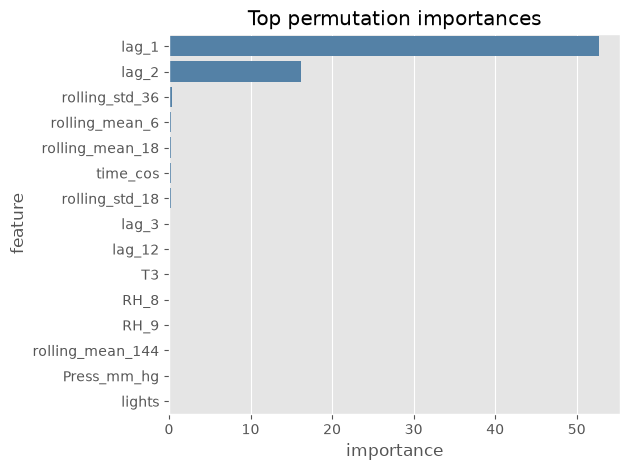

Workflow complete: compare the final holdout table, then use the error analysis to decide the next feature or model improvement.


In [398]:
importance = permutation_importance(tuned_model, X_test, y_test, n_repeats=3, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error', n_jobs=-1)
importance_df = pd.DataFrame({'feature': X_test.columns, 'importance': importance.importances_mean}).sort_values('importance', ascending=False)
display(importance_df.head(20))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', color='steelblue'); plt.title('Top permutation importances'); plt.tight_layout(); plt.show()
print('Workflow complete: compare the final holdout table, then use the error analysis to decide the next feature or model improvement.')
